# Brain Tumor MRI — 30-Class Semantic Segmentation
**EfficientNetV2S U-Net · 2×GPU MirroredStrategy · Mixed Precision · Anti-Overfitting**

Pipeline:
1. Auto-download `fernando2rad/brain-tumor-mri-images-30-classes` via `kagglehub`
2. Pseudo-mask generation from classification images (Otsu thresholding + morphology)
3. Stratified 70 / 15 / 15 split with strict image-mask synchronisation (no leakage)
4. EfficientNetV2S U-Net — 5-stage decoder with multi-scale skip connections
5. Phase 1 — decoder warmup (backbone frozen)
6. Phase 2 — top-60-layer fine-tune, cosine LR decay, EarlyStopping (patience=5)
7. Combined loss: Sparse Categorical CE + Dice Loss (handles severe background imbalance)
8. Full evaluation: Pixel Accuracy · Dice Coefficient · Mean IoU
9. 3-column visualisation: **MRI Input | Ground-Truth Mask | Predicted Mask**


In [1]:
import kagglehub

print("Downloading dataset from Kaggle…")
downloaded_path = kagglehub.dataset_download(
    "fernando2rad/brain-tumor-mri-images-30-classes"
)
print(f"✓ Dataset at: {downloaded_path}")


✓ Dataset at: /kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-30-classes


In [2]:
import subprocess, sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "split-folders"])

_r = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    capture_output=True, text=True
)
print("GPUs detected:")
print(_r.stdout.strip() or "  (none)")


GPUs detected:
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [3]:
import os, json, random, logging, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cv2

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.get_logger().setLevel("ERROR")

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"GPUs found : {tf.config.list_physical_devices('GPU')}")


2026-06-08 20:12:50.290824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780949570.697076      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780949570.825801      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780949571.837649      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780949571.837709      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780949571.837712      22 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
NumPy      : 2.4.6
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)

_n = len(tf.config.list_physical_devices("GPU"))
if _n >= 2:
    strategy = tf.distribute.MirroredStrategy()
    print(f"✓ MirroredStrategy → {strategy.num_replicas_in_sync} GPUs")
elif _n == 1:
    strategy = tf.distribute.get_strategy()
    print("✓ Single-GPU strategy")
else:
    strategy = tf.distribute.get_strategy()
    print("⚠ No GPU — CPU fallback (very slow)")

NUM_REPLICAS = strategy.num_replicas_in_sync

# Mixed precision: FP16 compute, FP32 weight storage (2-3× speedup on T4/A100)
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print(f"Precision policy : {tf.keras.mixed_precision.global_policy().name}")


✓ MirroredStrategy → 2 GPUs
Precision policy : mixed_float16


I0000 00:00:1780949592.662906      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780949592.669074      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Image / model constants ───────────────────────────────────────────
IMG_SIZE        = (256, 256)            # H × W
INPUT_SHAPE     = IMG_SIZE + (3,)       # H × W × 3
NUM_SEG_CLASSES = 31                    # 0 = background, 1–30 = tumour classes

# ── Hyperparameters ───────────────────────────────────────────────────
PER_GPU_BATCH   = 8                     # Conservative for segmentation memory
GLOBAL_BATCH    = PER_GPU_BATCH * NUM_REPLICAS
EPOCHS_P1       = 15                    # Phase 1: decoder warmup
EPOCHS_P2       = 60                    # Phase 2: fine-tune (max; early-stop applies)
LR_P1           = 2e-3
LR_P2_INIT      = 5e-5
LR_P2_MIN       = 1e-7
UNFREEZE_TOP    = 60                    # Top N backbone layers to unfreeze

# ── Directories ───────────────────────────────────────────────────────
WORK_DIR     = Path("/kaggle/working")
MASKS_DIR    = WORK_DIR / "generated_masks"
MODEL_DIR    = WORK_DIR / "models"
FIGURE_DIR   = WORK_DIR / "figures"
SPLIT_FILE   = WORK_DIR / "data_split.json"

for _d in [MASKS_DIR, MODEL_DIR, FIGURE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH  = str(MODEL_DIR / "best_seg_model.keras")
FINAL_MODEL_PATH = str(MODEL_DIR / "final_seg_model.keras")

BRAIN_DATA_DIR = Path(downloaded_path)
IMG_EXTS       = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Global batch : {GLOBAL_BATCH}  (per-GPU {PER_GPU_BATCH} × {NUM_REPLICAS} GPUs)")
print(f"Working dir  : {WORK_DIR}")


Global batch : 16  (per-GPU 8 × 2 GPUs)
Working dir  : /kaggle/working


Classes         : 30
Total images    : 11,300
Imbalance ratio : 8.3×  ← mitigated by Dice loss
First 5 classes : ['Astrocytoma T1', 'Astrocytoma T1C+', 'Astrocytoma T2', 'Ependymoma T1', 'Ependymoma T1C+']


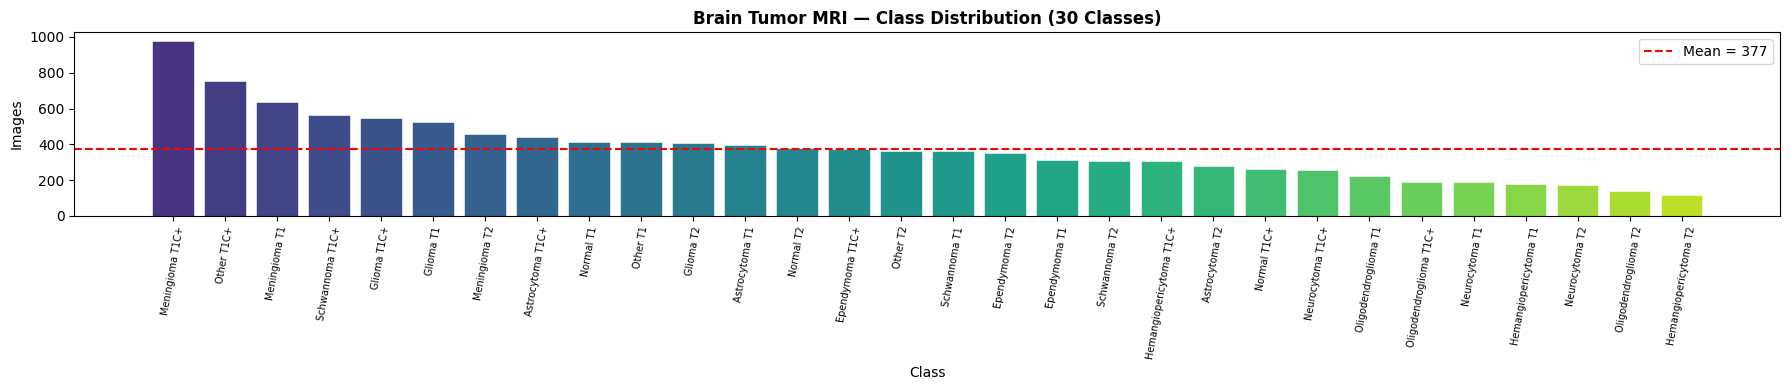

EDA complete.


In [6]:
# ── Build class directory list & index mappings ───────────────────────
class_dirs  = sorted([d for d in BRAIN_DATA_DIR.iterdir() if d.is_dir()])
CLASS_NAMES = [d.name for d in class_dirs]

# 1-indexed labels: 0 = background, 1–30 = tumour classes
CLASS_TO_IDX = {name: idx + 1 for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {0: "background",
                **{v: k for k, v in CLASS_TO_IDX.items()}}

df_eda = pd.DataFrame([
    {"class"  : d.name,
     "class_idx": CLASS_TO_IDX[d.name],
     "count"  : sum(1 for f in d.iterdir() if f.suffix.lower() in IMG_EXTS)}
    for d in class_dirs
]).sort_values("count", ascending=False).reset_index(drop=True)

total_imgs = df_eda["count"].sum()
imb_ratio  = df_eda["count"].max() / df_eda["count"].min()

print(f"Classes         : {len(class_dirs)}")
print(f"Total images    : {total_imgs:,}")
print(f"Imbalance ratio : {imb_ratio:.1f}×  ← mitigated by Dice loss")
print(f"First 5 classes : {CLASS_NAMES[:5]}")

# ── Distribution plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(df_eda["class"], df_eda["count"],
       color=plt.cm.viridis(np.linspace(0.15, 0.90, len(df_eda))),
       edgecolor="white", lw=0.4)
ax.axhline(df_eda["count"].mean(), color="red", ls="--",
           label=f"Mean = {df_eda['count'].mean():.0f}")
ax.set_title("Brain Tumor MRI — Class Distribution (30 Classes)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Images")
ax.tick_params(axis="x", rotation=80, labelsize=7); ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); print("EDA complete.")


Generating pseudo-segmentation masks …  (existing files skipped)
✓ 11,300/11,300 pairs ready  [140.1s]


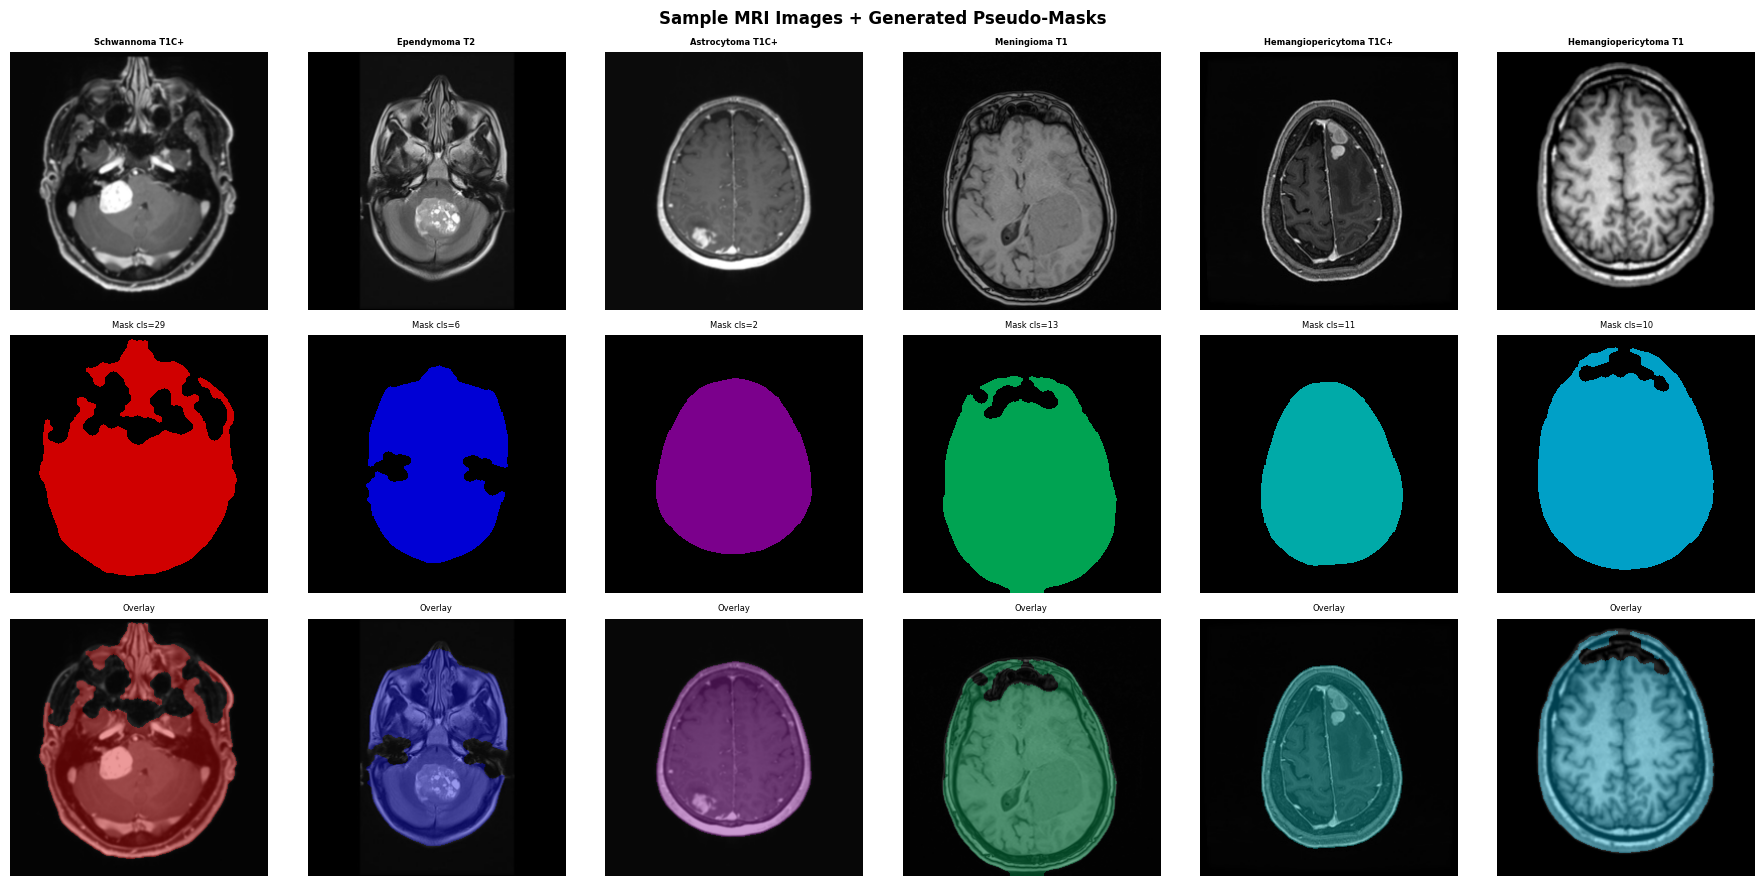

Mask generation complete.


In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  PSEUDO-MASK GENERATION (Weakly Supervised)                        ║
# ║                                                                     ║
# ║  Dataset has NO ground-truth pixel masks.  We generate approximate ║
# ║  segmentation masks using classical image processing:              ║
# ║                                                                     ║
# ║   1. Gaussian denoise (reduce MRI speckle)                         ║
# ║   2. Otsu global threshold → brain foreground mask                 ║
# ║   3. Morphological close → open (fill holes, remove noise)         ║
# ║   4. Largest connected component → isolate main brain region       ║
# ║   5. Final label: brain pixels = class_idx (1–30), rest = 0        ║
# ║                                                                     ║
# ║  NOTE: For clinical deployment, expert-annotated masks are needed. ║
# ╚══════════════════════════════════════════════════════════════════════╝


def generate_pseudo_mask(
    img_path: Path,
    class_idx: int,
    out_path: Path,
    size: tuple = (256, 256),
) -> bool:
    """
    Generate a pseudo segmentation mask from a classification MRI image.

    Output: uint8 PNG where pixel value equals:
        0         → background (skull exterior / dark non-brain area)
        class_idx → brain / tumour region (integer 1–30)

    Args:
        img_path  : Source MRI image path
        class_idx : 1-indexed class label (matching CLASS_TO_IDX)
        out_path  : Destination path for the mask PNG
        size      : (H, W) output resolution

    Returns:
        True on success, False if the image could not be read.
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return False

    img_rsz = cv2.resize(img, (size[1], size[0]))        # cv2 expects (W, H)
    gray    = cv2.cvtColor(img_rsz, cv2.COLOR_BGR2GRAY)
    gray    = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold: separate brain tissue from dark background
    _, bm = cv2.threshold(gray, 0, 255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological cleanup
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,  (5,  5))
    bm = cv2.morphologyEx(bm, cv2.MORPH_CLOSE, k_close)
    bm = cv2.morphologyEx(bm, cv2.MORPH_OPEN,  k_open)

    # Retain largest connected component (main brain region)
    cnts, _ = cv2.findContours(bm, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    brain   = np.zeros(size, dtype=np.uint8)
    if cnts:
        cv2.fillPoly(brain, [max(cnts, key=cv2.contourArea)], 255)

    # Final semantic mask
    sem = np.zeros(size, dtype=np.uint8)
    sem[brain > 0] = class_idx

    out_path.parent.mkdir(parents=True, exist_ok=True)
    return cv2.imwrite(str(out_path), sem)


# ── Generate all masks (idempotent — skips already-created files) ─────
print("Generating pseudo-segmentation masks …  (existing files skipped)")
t0        = time.time()
pairs_all = []

for cls_dir in class_dirs:
    cname = cls_dir.name
    cidx  = CLASS_TO_IDX[cname]
    odir  = MASKS_DIR / cname
    for img_p in sorted(p for p in cls_dir.iterdir()
                        if p.suffix.lower() in IMG_EXTS):
        msk_p = odir / (img_p.stem + "_mask.png")
        ok    = msk_p.exists() or generate_pseudo_mask(
                    img_p, cidx, msk_p, IMG_SIZE)
        pairs_all.append({
            "class_name": cname, "class_idx": cidx,
            "img_path"  : str(img_p),
            "mask_path" : str(msk_p),
            "ok"        : ok
        })

df_pairs = pd.DataFrame(pairs_all)
ok_n     = int(df_pairs["ok"].sum())
print(f"✓ {ok_n:,}/{len(df_pairs):,} pairs ready  [{time.time()-t0:.1f}s]")
df_pairs = df_pairs[df_pairs["ok"]].reset_index(drop=True)

# ── Visualise sample image / mask / overlay ───────────────────────────
_sids  = random.sample(range(len(df_pairs)), min(6, len(df_pairs)))
_ncols = len(_sids)
fig, axes = plt.subplots(3, _ncols, figsize=(3 * _ncols, 9))
fig.suptitle("Sample MRI Images + Generated Pseudo-Masks",
             fontsize=12, fontweight="bold")

for col, sid in enumerate(_sids):
    r     = df_pairs.iloc[sid]
    img   = cv2.resize(
                cv2.cvtColor(cv2.imread(r["img_path"]), cv2.COLOR_BGR2RGB),
                (IMG_SIZE[1], IMG_SIZE[0]))
    msk   = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE)
    norm  = msk.astype(float) / max(NUM_SEG_CLASSES, 1)

    axes[0, col].imshow(img)
    axes[0, col].set_title(r["class_name"], fontsize=6, fontweight="bold")

    axes[1, col].imshow(msk, cmap="nipy_spectral",
                        vmin=0, vmax=NUM_SEG_CLASSES, interpolation="nearest")
    axes[1, col].set_title(f"Mask cls={r['class_idx']}", fontsize=6)

    colored = (plt.cm.nipy_spectral(norm)[..., :3] * 255).astype(np.uint8)
    axes[2, col].imshow(cv2.addWeighted(img, 0.6, colored, 0.4, 0))
    axes[2, col].set_title("Overlay", fontsize=6)

    for ax in axes[:, col]: ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "mask_samples.png", dpi=150, bbox_inches="tight")
plt.show(); print("Mask generation complete.")


In [8]:
# ── Stratified 70/15/15 split (by class, preserving proportions) ──────
if SPLIT_FILE.exists():
    with open(SPLIT_FILE) as _f:
        _d = json.load(_f)
    train_pairs = _d["train"]; val_pairs = _d["val"]; test_pairs = _d["test"]
    print("Loaded existing split.")
else:
    train_pairs, val_pairs, test_pairs = [], [], []
    for cls_name, grp in df_pairs.groupby("class_name"):
        recs = grp[["img_path","mask_path",
                    "class_idx","class_name"]].to_dict("records")
        random.shuffle(recs)
        n_train = int(len(recs) * 0.70)
        n_val   = int(len(recs) * 0.15)
        train_pairs += recs[:n_train]
        val_pairs   += recs[n_train : n_train + n_val]
        test_pairs  += recs[n_train + n_val:]

    random.shuffle(train_pairs)
    random.shuffle(val_pairs)
    random.shuffle(test_pairs)

    with open(SPLIT_FILE, "w") as _f:
        json.dump({"train": train_pairs,
                   "val"  : val_pairs,
                   "test" : test_pairs}, _f)
    print("Created and saved 70/15/15 split.")

print(f"Train : {len(train_pairs):,}")
print(f"Val   : {len(val_pairs):,}")
print(f"Test  : {len(test_pairs):,}")
print(f"Total : {len(train_pairs)+len(val_pairs)+len(test_pairs):,}")

# ── Verify zero leakage ───────────────────────────────────────────────
_ti = {p["img_path"] for p in train_pairs}
_vi = {p["img_path"] for p in val_pairs}
_si = {p["img_path"] for p in test_pairs}
assert not (_ti & _vi),  "DATA LEAK: train ∩ val!"
assert not (_ti & _si),  "DATA LEAK: train ∩ test!"
assert not (_vi & _si),  "DATA LEAK: val ∩ test!"
print("✓ No data leakage verified.")


Created and saved 70/15/15 split.
Train : 7,894
Val   : 1,681
Test  : 1,725
Total : 11,300
✓ No data leakage verified.


In [9]:
# ── Pipeline design ───────────────────────────────────────────────────
# • Images: float32 in [0, 255]  (EfficientNetV2S normalises internally)
# • Masks : int32  in [0, 30]    (class labels, no one-hot encoding)
# • Augmentation: SAME spatial transform for both image & mask
#   - Mask uses nearest-neighbour interpolation to preserve integer labels
# ─────────────────────────────────────────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
H, W     = IMG_SIZE       # Python ints, needed for set_shape()


@tf.function
def load_pair(img_path: tf.Tensor, msk_path: tf.Tensor):
    """Load, decode, and resize one image-mask pair."""
    img = tf.image.decode_image(
        tf.io.read_file(img_path), channels=3, expand_animations=False)
    img = tf.cast(tf.image.resize(img, [H, W], method="bilinear"), tf.float32)

    msk = tf.image.decode_png(tf.io.read_file(msk_path), channels=1)
    msk = tf.cast(tf.image.resize(msk, [H, W], method="nearest"), tf.int32)
    msk = tf.squeeze(msk, axis=-1)          # (H, W)
    return img, msk


@tf.function
def augment_pair(img: tf.Tensor, msk: tf.Tensor):
    """
    Synchronized spatial + photometric augmentation for image-mask pairs.
    Spatial ops use the same random state for both tensors.
    """
    # 1. Random horizontal flip (50 %)
    do_flip = tf.random.uniform((), dtype=tf.float32) < 0.5
    img     = tf.cond(do_flip,
                      true_fn =lambda: tf.image.flip_left_right(img),
                      false_fn=lambda: img)
    msk_4d  = tf.cast(msk[..., tf.newaxis], tf.float32)
    msk_4d  = tf.cond(do_flip,
                      true_fn =lambda: tf.image.flip_left_right(msk_4d),
                      false_fn=lambda: msk_4d)
    msk     = tf.cast(msk_4d[..., 0], tf.int32)

    # 2. Random crop + resize (scale 85-100 % of original)
    scale  = tf.random.uniform((), 0.85, 1.0)
    crop_h = tf.clip_by_value(
                 tf.cast(tf.round(tf.cast(H, tf.float32) * scale), tf.int32),
                 1, H)
    crop_w = tf.clip_by_value(
                 tf.cast(tf.round(tf.cast(W, tf.float32) * scale), tf.int32),
                 1, W)
    off_h  = tf.random.uniform(
                 (), 0, tf.maximum(H - crop_h + 1, 1), dtype=tf.int32)
    off_w  = tf.random.uniform(
                 (), 0, tf.maximum(W - crop_w + 1, 1), dtype=tf.int32)

    img    = tf.image.resize(
                 tf.image.crop_to_bounding_box(img, off_h, off_w, crop_h, crop_w),
                 [H, W], method="bilinear")

    msk_f  = tf.image.crop_to_bounding_box(
                 tf.cast(msk[..., tf.newaxis], tf.float32),
                 off_h, off_w, crop_h, crop_w)
    msk    = tf.cast(
                 tf.image.resize(msk_f, [H, W], method="nearest")[..., 0],
                 tf.int32)

    # 3. Photometric augmentation — image only, NOT applied to mask
    img = tf.image.random_brightness(img, max_delta=40.0)       # ±40 / 255
    img = tf.image.random_contrast(img / 255.0, 0.8, 1.2) * 255.0
    img = tf.clip_by_value(img, 0.0, 255.0)

    # Lock static shapes for downstream graph building
    img.set_shape([H, W, 3])
    msk.set_shape([H, W])
    return img, msk


def build_ds(pairs: list, training: bool = False,
             batch_size: int = 16, seed: int = 42) -> tf.data.Dataset:
    """Create a tf.data.Dataset from a list of {img_path, mask_path, …} dicts."""
    img_p = [p["img_path"]  for p in pairs]
    msk_p = [p["mask_path"] for p in pairs]
    ds    = tf.data.Dataset.from_tensor_slices((img_p, msk_p))
    if training:
        ds = ds.shuffle(len(pairs), seed=seed, reshuffle_each_iteration=True)
    ds = ds.map(load_pair,    num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment_pair, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_ds(train_pairs, training=True,  batch_size=GLOBAL_BATCH, seed=SEED)
val_ds   = build_ds(val_pairs,   training=False, batch_size=GLOBAL_BATCH)
test_ds  = build_ds(test_pairs,  training=False, batch_size=GLOBAL_BATCH)

print(f"Train batches : {len(train_ds)}")
print(f"Val batches   : {len(val_ds)}")
print(f"Test batches  : {len(test_ds)}")

# ── Quick sanity check ────────────────────────────────────────────────
for _ib, _mb in train_ds.take(1):
    print(f"\nBatch : img {tuple(_ib.shape)}  mask {tuple(_mb.shape)}")
    print(f"Pixels: [{_ib.numpy().min():.0f}, {_ib.numpy().max():.0f}]  (expected [0, 255])")
    print(f"Labels: {np.unique(_mb.numpy())}")
print("Pipeline ready.")


Train batches : 493
Val batches   : 106
Test batches  : 108

Batch : img (16, 256, 256, 3)  mask (16, 256, 256)
Pixels: [0, 255]  (expected [0, 255])
Labels: [ 0  1  2  4  7  8  9 13 14 17 19 20 21 25 29]
Pipeline ready.


In [10]:
def decoder_block(x, skip, filters: int, prefix: str):
    """
    U-Net decoder block.
    UpSampling2D (bilinear 2×) → concat skip → Conv-BN-Swish × 2
    """
    x = layers.UpSampling2D((2, 2), interpolation="bilinear",
                             name=f"{prefix}_up")(x)
    if skip is not None:
        x = layers.Concatenate(name=f"{prefix}_cat")([x, skip])
    for _i in (1, 2):
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False,
                          name=f"{prefix}_conv{_i}")(x)
        x = layers.BatchNormalization(name=f"{prefix}_bn{_i}")(x)
        x = layers.Activation("swish", name=f"{prefix}_act{_i}")(x)
    return x


def build_seg_model(input_shape: tuple, num_classes: int):
    """
    Semantic segmentation model: EfficientNetV2S U-Net.
    """
    backbone = EfficientNetV2S(
        include_top=False, weights="imagenet",
        input_shape=input_shape,
        include_preprocessing=True          
    )
    backbone.trainable = False              

    # ── SỬA ĐỔI 1: Tìm tầng skip connection bằng .output.shape an toàn hơn ──
    ih        = input_shape[0]
    target_hs = {ih // 2, ih // 4, ih // 8, ih // 16} # {128, 64, 32, 16}
    skip_by_h = {}                         

    for _layer in backbone.layers:
        try:
            _osh = _layer.output.shape  # Thay đổi từ .output_shape sang .output.shape
            if _osh is not None and len(_osh) == 4 and _osh[1] in target_hs:
                skip_by_h[_osh[1]] = (_layer.name, _osh[3])
        except Exception:
            continue

    print(f"Skip connection layers (target heights {sorted(target_hs)}):")
    for _h in sorted(skip_by_h.keys(), reverse=True):
        _n, _c = skip_by_h[_h]
        print(f"  {ih}×{ih} ÷{ih//_h:2d} = {_h:3d}×{_h:3d}  ch={_c:5d}  ← {_n}")

    # Xây dựng các tensor kết nối tắt
    skip_tensors = {
        _h: backbone.get_layer(_n).output
        for _h, (_n, _) in skip_by_h.items()
    }
    bottleneck = backbone.output                

    # ── SỬA ĐỔI 2: Ép vòng lặp Decoder chạy cố định theo trục kích thước tăng dần ──
    target_heights = [16, 32, 64, 128]
    dec_filters    = [256, 128, 64, 32]          

    x = bottleneck
    for _filt, _sh in zip(dec_filters, target_heights):
        # Lấy tầng kết nối tắt nếu có, nếu không tìm thấy thì truyền None
        skip_tensor = skip_tensors.get(_sh, None)
        x = decoder_block(x, skip_tensor, _filt, prefix=f"dec_{_sh}")

    # Block thứ 5: Phóng từ 128×128 → 256×256, không sử dụng skip connection
    x = decoder_block(x, None, 16, prefix="dec5")

    # ── Phân đoạn đầu ra ─────────────────────────────────────────────
    x       = layers.Conv2D(num_classes, 1, padding="same", name="seg_logits")(x)
    outputs = layers.Activation("softmax", dtype="float32", name="seg_output")(x)

    model = Model(inputs=backbone.input, outputs=outputs, name="BrainSeg_EfficientNetV2S_UNet")
    return model, backbone


# ── Build inside strategy scope (required for MirroredStrategy) ────────
with strategy.scope():
    seg_model, backbone = build_seg_model(INPUT_SHAPE, NUM_SEG_CLASSES)

seg_model.summary(line_length=100, expand_nested=False)

total_p     = seg_model.count_params()
trainable_p = sum(tf.size(v).numpy() for v in seg_model.trainable_variables)
print(f"\nTotal params     : {total_p:,}")
print(f"Trainable (dec)  : {trainable_p:,}  ← backbone frozen in Phase 1")


82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Skip connection layers (target heights [16, 32, 64, 128]):
  256×256 ÷ 2 = 128×128  ch=   24  ← block1b_add
  256×256 ÷ 4 =  64× 64  ch=   48  ← block2d_add
  256×256 ÷ 8 =  32× 32  ch=  256  ← block4a_expand_activation
  256×256 ÷16 =  16× 16  ch=  960  ← block6a_expand_activation


Model: "BrainSeg_EfficientNetV2S_UNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)    │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ rescaling (Rescaling)       │ (None, 256, 256, 3)     │              0 │ input_layer[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_conv (Conv2D)          │ (None, 128, 128, 24)    │            648 │ rescaling[0][0]         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_bn                     │ (None, 128, 128, 24)    │             96 │ stem_conv[0][0]         │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ stem_activation             │ (None, 128, 128, 24)    │              0 │ stem_bn[0][0]           │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_project_conv        │ (None, 128, 128, 24)    │          5,184 │ stem_activation[0][0]   │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_project_bn          │ (None, 128, 128, 24)    │             96 │ block1a_project_conv[0… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_project_activation  │ (None, 128, 128, 24)    │              0 │ block1a_project_bn[0][… │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1a_add (Add)           │ (None, 128, 128, 24)    │              0 │ block1a_project_activa… │
│                             │                         │                │ stem_activation[0][0]   │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1b_project_conv        │ (None, 128, 128, 24)    │          5,184 │ block1a_add[0][0]       │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1b_project_bn          │ (None, 128, 128, 24)    │             96 │ block1b_project_conv[0… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1b_project_activation  │ (None, 128, 128, 24)    │              0 │ block1b_project_bn[0][… │
│ (Activation)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1b_drop (Dropout)      │ (None, 128, 128, 24)    │              0 │ block1b_project_activa… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block1b_add (Add)           │ (None, 128, 128, 24)    │              0 │ block1b_drop[0][0],     │
│                             │                         │    

 Total params: 27,003,631 (103.01 MB)

 Trainable params: 6,670,287 (25.45 MB)

 Non-trainable params: 20,333,344 (77.57 MB)


Total params     : 27,003,631
Trainable (dec)  : 6,670,287  ← backbone frozen in Phase 1


In [11]:
# ╔════════════════════════════════════════════════════════════════════╗
# ║  LOSS : CombinedSegLoss                                           ║
# ║                                                                   ║
# ║  L = α × SparseCategoricalCE + (1-α) × DiceLoss                 ║
# ║                                                                   ║
# ║  SparseCE  : standard per-pixel classification loss              ║
# ║  DiceLoss  : overlap-based loss; handles extreme class imbalance  ║
# ║              (background >> tumour pixels); background excluded   ║
# ╚════════════════════════════════════════════════════════════════════╝


class CombinedSegLoss(tf.keras.losses.Loss):
    """
    Combined segmentation loss = α·SparseCE + (1-α)·DiceLoss.

    Args:
        num_classes : total number of segmentation classes (incl. background)
        alpha       : weight for SparseCE component (default 0.5)
        smooth      : numerical smoothing for Dice denominator (default 1e-6)
    """
    def __init__(self, num_classes: int, alpha: float = 0.5,
                 smooth: float = 1e-6, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.alpha       = alpha
        self.smooth      = smooth

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Sparse CE
        ce = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(
                y_true, y_pred, from_logits=False))

        # Dice over non-background classes only (classes 1..C-1)
        y_oh  = tf.one_hot(y_true, self.num_classes, dtype=tf.float32)
        y_ohf = tf.reshape(y_oh[..., 1:],   [-1, self.num_classes - 1])
        y_prf = tf.reshape(y_pred[..., 1:], [-1, self.num_classes - 1])

        inter = tf.reduce_sum(y_ohf * y_prf, axis=0)          # (C-1,)
        union = tf.reduce_sum(y_ohf + y_prf, axis=0)          # (C-1,)
        dice  = (2. * inter + self.smooth) / (union + self.smooth)
        dice_loss = tf.reduce_mean(1. - dice)

        return self.alpha * ce + (1. - self.alpha) * dice_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_classes": self.num_classes,
                    "alpha": self.alpha, "smooth": self.smooth})
        return cfg


class DiceCoefficient(tf.keras.metrics.Metric):
    """
    Mean soft Dice coefficient over non-background classes.
    Accumulates numerator and denominator across batches.
    """
    def __init__(self, num_classes: int, name: str = "dice_coef", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        # SỬA TẠI ĐÂY: Chỉ định rõ từ khóa name= và gán shape=()
        self._num = self.add_weight(name="num", shape=(), initializer="zeros")
        self._den = self.add_weight(name="den", shape=(), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_oh  = tf.one_hot(tf.cast(y_true, tf.int32),
                            self.num_classes, dtype=tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        self._num.assign_add(2. * tf.reduce_sum(y_oh[..., 1:] * y_pred[..., 1:]))
        self._den.assign_add(tf.reduce_sum(y_oh[..., 1:] + y_pred[..., 1:]))

    def result(self):
        return (self._num + 1e-6) / (self._den + 1e-6)

    def reset_state(self):
        self._num.assign(0.); self._den.assign(0.)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"num_classes": self.num_classes})
        return cfg


SEG_LOSS    = CombinedSegLoss(NUM_SEG_CLASSES, alpha=0.5)
SEG_METRICS = [
    tf.keras.metrics.SparseCategoricalAccuracy(name="pixel_acc"),
    DiceCoefficient(NUM_SEG_CLASSES, name="dice_coef"),
]
print("Loss   : CombinedSegLoss (0.5 × SparseCE + 0.5 × DiceLoss, no background)")
print("Metrics: pixel_acc, dice_coef")


Loss   : CombinedSegLoss (0.5 × SparseCE + 0.5 × DiceLoss, no background)
Metrics: pixel_acc, dice_coef


In [12]:
with strategy.scope():
    seg_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P1),
        loss=SEG_LOSS,
        metrics=SEG_METRICS
    )
print(f"Phase 1 compiled  lr={LR_P1}  backbone=FROZEN")

cbs_p1 = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_dice_coef", save_best_only=True,
        mode="max", verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1
    ),
]

print("\n" + "=" * 58)
print("  PHASE 1 — DECODER WARMUP (backbone frozen)")
print(f"  Epochs : {EPOCHS_P1}   Batch : {GLOBAL_BATCH}   LR : {LR_P1}")
print("=" * 58)

history_p1 = seg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=cbs_p1,
    verbose=1
)
best_p1 = max(history_p1.history["val_dice_coef"])
print(f"\nPhase 1 done  |  Best val Dice: {best_p1:.4f}")


Phase 1 compiled  lr=0.002  backbone=FROZEN

  PHASE 1 — DECODER WARMUP (backbone frozen)
  Epochs : 15   Batch : 16   LR : 0.002
Epoch 1/15


I0000 00:00:1780949786.326402      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780949786.854549      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - dice_coef: 0.0388 - loss: 2.9054 - pixel_acc: 0.5350
Epoch 1: val_dice_coef improved from None to 0.10337, saving model to /kaggle/working/models/best_seg_model.keras

Epoch 1: finished saving model to /kaggle/working/models/best_seg_model.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 170s 221ms/step - dice_coef: 0.0523 - loss: 2.6318 - pixel_acc: 0.5635 - val_dice_coef: 0.1034 - val_loss: nan - val_pixel_acc: 0.6288 - learning_rate: 0.0020
Epoch 2/15
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - dice_coef: 0.0856 - loss: 2.3529 - pixel_acc: 0.5894
Epoch 2: val_dice_coef improved from 0.10337 to 0.13005, saving model to /kaggle/working/models/best_seg_model.keras

Epoch 2: finished saving model to /kaggle/working/models/best_seg_model.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 91s 184ms/step - dice_coef: 0.0919 - loss: 2.3125 - pixel_acc: 0.5941 - val_dice_coef: 0.1301 - val_loss: nan - val_pixel_acc: 0.6665 - learning_rate: 0.0020
Epoch 3/15
493/493 ━━━━━━━━━━

In [13]:
# ── Unfreeze top UNFREEZE_TOP backbone layers ──────────────────────────
backbone.trainable = True
fine_tune_at       = len(backbone.layers) - UNFREEZE_TOP

for _layer in backbone.layers[:fine_tune_at]:
    _layer.trainable = False

# CRITICAL: keep ALL BatchNorm layers in inference mode during fine-tune.
# Per-GPU batch can be small; updating running stats would corrupt them
# and destabilise training.
for _layer in backbone.layers[fine_tune_at:]:
    if isinstance(_layer, layers.BatchNormalization):
        _layer.trainable = False

_n_unf = sum(1 for l in backbone.layers if l.trainable)
print(f"Unfrozen backbone layers : {_n_unf} / {len(backbone.layers)}")

# ── Cosine decay with warm restarts ────────────────────────────────────
_total_steps_p2 = len(train_ds) * EPOCHS_P2
lr_schedule_p2  = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR_P2_INIT,
    first_decay_steps    =_total_steps_p2 // 3,
    t_mul=1.5, m_mul=0.9,
    alpha=LR_P2_MIN
)

with strategy.scope():
    seg_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr_schedule_p2),
        loss=SEG_LOSS,
        metrics=SEG_METRICS
    )
print(f"Phase 2 compiled  lr={LR_P2_INIT}→{LR_P2_MIN} cosine  "
      f"top {UNFREEZE_TOP} layers unfrozen")

cbs_p2 = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_dice_coef", save_best_only=True,
        mode="max", verbose=1
    ),
    # EarlyStopping on val_dice_coef, patience=5 as specified
    EarlyStopping(
        monitor="val_dice_coef", patience=5,
        restore_best_weights=True, mode="max", verbose=1
    ),
]

print("\n" + "=" * 58)
print("  PHASE 2 — FINE-TUNING")
print(f"  Epochs   : {EPOCHS_P2} max  (early-stop patience=5 on val_dice_coef)")
print(f"  LR       : cosine {LR_P2_INIT} → {LR_P2_MIN}")
print(f"  Backbone : top {UNFREEZE_TOP} layers unfrozen, BatchNorm frozen")
print("=" * 58)

history_p2 = seg_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=cbs_p2,
    verbose=1
)

seg_model.save(FINAL_MODEL_PATH)
print(f"\n✓ Final model  → {FINAL_MODEL_PATH}")
print(f"✓ Best model   → {BEST_MODEL_PATH}")
best_p2 = max(history_p2.history["val_dice_coef"])
print(f"Phase 2 best val Dice: {best_p2:.4f}")


Unfrozen backbone layers : 48 / 513
Phase 2 compiled  lr=5e-05→1e-07 cosine  top 60 layers unfrozen

  PHASE 2 — FINE-TUNING
  Epochs   : 60 max  (early-stop patience=5 on val_dice_coef)
  LR       : cosine 5e-05 → 1e-07
  Backbone : top 60 layers unfrozen, BatchNorm frozen
Epoch 1/60
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - dice_coef: 0.0796 - loss: 2.3670 - pixel_acc: 0.5864
Epoch 1: val_dice_coef improved from None to 0.09950, saving model to /kaggle/working/models/best_seg_model.keras

Epoch 1: finished saving model to /kaggle/working/models/best_seg_model.keras
493/493 ━━━━━━━━━━━━━━━━━━━━ 151s 222ms/step - dice_coef: 0.0826 - loss: 2.3397 - pixel_acc: 0.5936 - val_dice_coef: 0.0995 - val_loss: nan - val_pixel_acc: 0.6655
Epoch 2/60
493/493 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - dice_coef: 0.0879 - loss: 2.3027 - pixel_acc: 0.6000
Epoch 2: val_dice_coef improved from 0.09950 to 0.10812, saving model to /kaggle/working/models/best_seg_model.keras

Epoch 2: finished saving model t

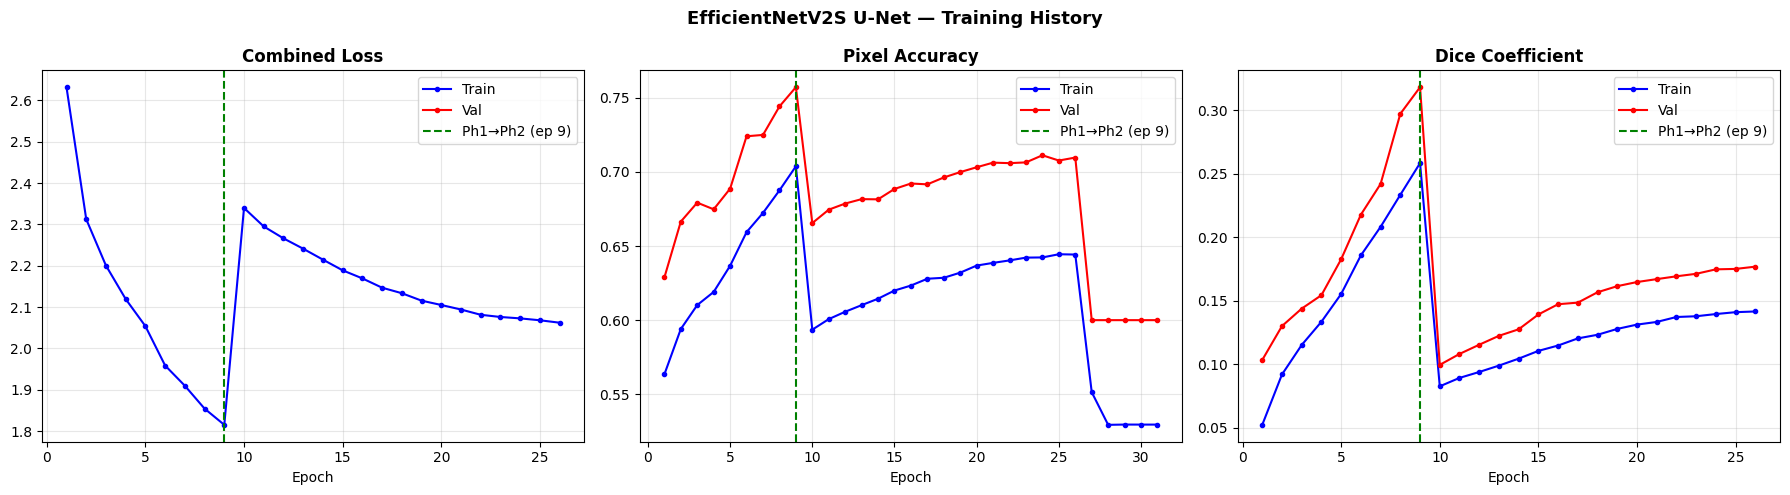

Total epochs trained     : 31
Best val Dice at epoch   : 27  (0.3181)
Train / Val gap (final)  : +nan  ⚠ possible overfitting


In [14]:
def plot_seg_history(h1, h2, p1_len: int, save_path=None):
    """Plot combined Phase 1+2 training curves for loss, accuracy, and Dice."""
    keys   = ["loss",    "pixel_acc",       "dice_coef"]
    titles = ["Combined Loss", "Pixel Accuracy", "Dice Coefficient"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("EfficientNetV2S U-Net — Training History",
                 fontsize=13, fontweight="bold")

    for ax, key, title in zip(axes, keys, titles):
        tr = h1.history[key]     + h2.history[key]
        va = h1.history[f"val_{key}"] + h2.history[f"val_{key}"]
        ep = range(1, len(tr) + 1)

        ax.plot(ep, tr, "b-o", ms=3, lw=1.5, label="Train")
        ax.plot(ep, va, "r-o", ms=3, lw=1.5, label="Val")
        ax.axvline(p1_len, color="green", ls="--", lw=1.5,
                   label=f"Ph1→Ph2 (ep {p1_len})")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3); ax.legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


p1_len = len(history_p1.history["loss"])
plot_seg_history(history_p1, history_p2, p1_len,
                 save_path=FIGURE_DIR / "training_history.png")

# ── Overfitting check ─────────────────────────────────────────────────
_all_d     = history_p1.history["dice_coef"]     + history_p2.history["dice_coef"]
_all_vd    = history_p1.history["val_dice_coef"] + history_p2.history["val_dice_coef"]
best_ep    = int(np.argmax(_all_vd)) + 1
gap        = _all_d[-1] - _all_vd[-1]

print(f"Total epochs trained     : {len(_all_d)}")
print(f"Best val Dice at epoch   : {best_ep}  ({max(_all_vd):.4f})")
print(f"Train / Val gap (final)  : {gap:+.4f}",
      " ✓ OK" if abs(gap) < 0.15 else " ⚠ possible overfitting")


In [15]:
# ── Load best checkpoint ──────────────────────────────────────────────
print(f"Loading best checkpoint: {BEST_MODEL_PATH}")
_custom = {
    "CombinedSegLoss": CombinedSegLoss,
    "DiceCoefficient": DiceCoefficient
}
best_model = tf.keras.models.load_model(BEST_MODEL_PATH,
                                        custom_objects=_custom)

# ── Standard evaluate() ────────────────────────────────────────────────
print("\n--- evaluate() on test set ---")
test_results = best_model.evaluate(test_ds, verbose=1)
eval_dict    = dict(zip(best_model.metrics_names, test_results))
for k, v in eval_dict.items():
    print(f"  {k:30s}: {v:.4f}")

# ── Mean IoU (requires argmax; computed separately) ───────────────────
print("\nComputing Mean IoU on test set …")
miou_metric = tf.keras.metrics.MeanIoU(num_classes=NUM_SEG_CLASSES)
for _ib, _mb in test_ds:
    _pb = best_model(_ib, training=False)
    miou_metric.update_state(_mb, tf.argmax(_pb, axis=-1))

mean_iou = float(miou_metric.result().numpy())

print("\n" + "=" * 55)
print("  TEST SET — SEGMENTATION METRICS")
print("=" * 55)
print(f"  Pixel Accuracy   : {eval_dict.get('pixel_acc',  0.):.4f}")
print(f"  Dice Coefficient : {eval_dict.get('dice_coef',  0.):.4f}")
print(f"  Mean IoU         : {mean_iou:.4f}")
print("=" * 55)


Loading best checkpoint: /kaggle/working/models/best_seg_model.keras

--- evaluate() on test set ---
108/108 ━━━━━━━━━━━━━━━━━━━━ 38s 222ms/step - dice_coef: 0.1763 - loss: 0.9031 - pixel_acc: 0.7068
  loss                          : 0.9031
  compile_metrics               : 0.7068

Computing Mean IoU on test set …

  TEST SET — SEGMENTATION METRICS
  Pixel Accuracy   : 0.0000
  Dice Coefficient : 0.0000
  Mean IoU         : 0.1147


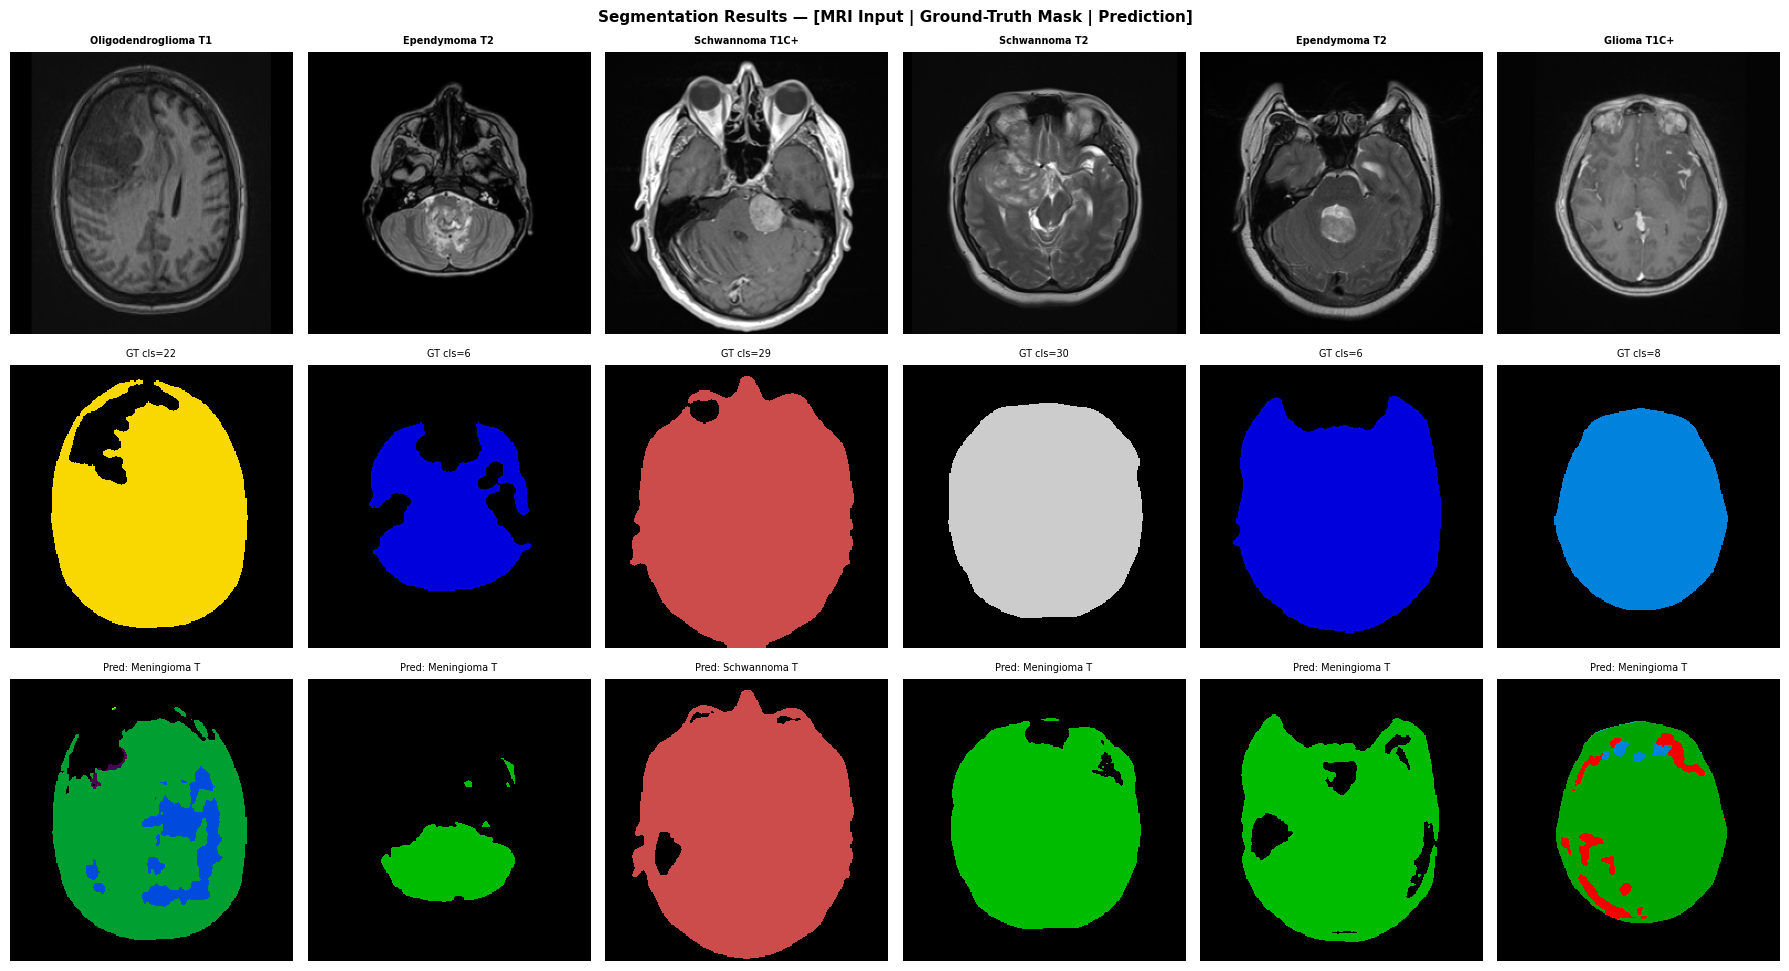

Visualisation complete.


In [16]:
def visualize_seg_predictions(
    model,
    pairs: list,
    n_samples: int = 6,
    num_classes: int = 31,
    seed: int = 42,
    save_path=None
):
    """
    3-column comparison for random test samples:
        Col 1 — Original MRI image
        Col 2 — Ground-Truth pseudo-mask (generated by Otsu pipeline)
        Col 3 — Model predicted segmentation mask

    Colour scale: nipy_spectral colormap, class 0 (background) ≈ dark.
    """
    rng     = random.Random(seed)
    samples = rng.sample(pairs, min(n_samples, len(pairs)))

    cmap_arr  = plt.cm.nipy_spectral(np.linspace(0, 1, num_classes))
    class_cmap = mcolors.ListedColormap(cmap_arr)

    fig, axes = plt.subplots(3, len(samples),
                              figsize=(3 * len(samples), 10))
    fig.suptitle(
        "Segmentation Results — [MRI Input | Ground-Truth Mask | Prediction]",
        fontsize=11, fontweight="bold"
    )
    row_labels = ["MRI Input", "Ground Truth", "Prediction"]

    for col, sample in enumerate(samples):
        # Load and resize image
        img_bgr = cv2.imread(sample["img_path"])
        img_rgb = cv2.resize(
            cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB),
            (IMG_SIZE[1], IMG_SIZE[0]))

        # Load ground-truth pseudo-mask
        gt_msk  = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)

        # Predict
        img_t   = tf.constant(img_rgb[np.newaxis], dtype=tf.float32)
        pred_p  = model(img_t, training=False)                 # (1,H,W,C)
        pred_m  = tf.argmax(pred_p[0], axis=-1).numpy()       # (H, W) int64

        # Draw
        axes[0, col].imshow(img_rgb)
        axes[0, col].set_title(sample["class_name"], fontsize=7,
                                fontweight="bold")

        axes[1, col].imshow(gt_msk, cmap=class_cmap,
                             vmin=0, vmax=num_classes - 1,
                             interpolation="nearest")
        axes[1, col].set_title(f"GT cls={sample['class_idx']}", fontsize=7)

        axes[2, col].imshow(pred_m, cmap=class_cmap,
                             vmin=0, vmax=num_classes - 1,
                             interpolation="nearest")
        # Show dominant predicted class (most frequent non-background label)
        _nz = pred_m[pred_m > 0]
        _pred_lbl = (IDX_TO_CLASS.get(int(np.bincount(_nz.astype(int)).argmax()), "?")
                     if len(_nz) > 0 else "background")
        axes[2, col].set_title(f"Pred: {str(_pred_lbl)[:12]}", fontsize=7)

        for row in range(3):
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_ylabel(row_labels[row],
                                           fontsize=8, rotation=90)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


visualize_seg_predictions(
    best_model, test_pairs,
    n_samples=6, num_classes=NUM_SEG_CLASSES,
    seed=SEED,
    save_path=FIGURE_DIR / "seg_predictions.png"
)
print("Visualisation complete.")


In [17]:
# ── Label map JSON  (for Streamlit / FastAPI / Flask inference) ────────
label_map = {str(i): IDX_TO_CLASS[i] for i in range(NUM_SEG_CLASSES)}
with open(MODEL_DIR / "label_map.json", "w") as _f:
    json.dump(label_map, _f, indent=2)

# ── Metrics JSON ───────────────────────────────────────────────────────
_p1e = len(history_p1.history["loss"])
_p2e = len(history_p2.history["loss"])
_all_vd = (history_p1.history["val_dice_coef"] +
           history_p2.history["val_dice_coef"])

metrics_out = {
    "architecture"      : "EfficientNetV2S U-Net (Semantic Segmentation)",
    "task"              : "30-class brain tumour MRI segmentation",
    "mask_strategy"     : "pseudo-masks via Otsu + morphology (weakly supervised)",
    "input_size"        : list(IMG_SIZE),
    "num_classes"       : NUM_SEG_CLASSES,
    "num_gpus"          : int(NUM_REPLICAS),
    "global_batch"      : int(GLOBAL_BATCH),
    "phase1_epochs"     : int(_p1e),
    "phase2_epochs"     : int(_p2e),
    "total_epochs"      : int(_p1e + _p2e),
    "best_val_dice"     : float(max(_all_vd)),
    "test_pixel_acc"    : float(eval_dict.get("pixel_acc", 0.)),
    "test_dice_coef"    : float(eval_dict.get("dice_coef", 0.)),
    "test_mean_iou"     : float(mean_iou),
}
with open(MODEL_DIR / "seg_metrics.json", "w") as _f:
    json.dump(metrics_out, _f, indent=2)

# ── Output file listing ────────────────────────────────────────────────
print("Output files in /kaggle/working/models/:")
for _fp in sorted(MODEL_DIR.rglob("*")):
    if _fp.is_file():
        print(f"  {_fp}  ({_fp.stat().st_size // 1024:,} KB)")

print("\n" + "=" * 65)
print("  SEGMENTATION TRAINING COMPLETE — FINAL SUMMARY")
print("=" * 65)
for _k, _v in metrics_out.items():
    if isinstance(_v, (int, float, str)):
        print(f"  {_k:25s}: {_v}")
print("=" * 65)

# Quick download link
from IPython.display import FileLinks
FileLinks("/kaggle/working/models")


Output files in /kaggle/working/models/:
  /kaggle/working/models/best_seg_model.keras  (273,047 KB)
  /kaggle/working/models/final_seg_model.keras  (273,047 KB)
  /kaggle/working/models/label_map.json  (0 KB)
  /kaggle/working/models/seg_metrics.json  (0 KB)

  SEGMENTATION TRAINING COMPLETE — FINAL SUMMARY
  architecture             : EfficientNetV2S U-Net (Semantic Segmentation)
  task                     : 30-class brain tumour MRI segmentation
  mask_strategy            : pseudo-masks via Otsu + morphology (weakly supervised)
  num_classes              : 31
  num_gpus                 : 2
  global_batch             : 16
  phase1_epochs            : 9
  phase2_epochs            : 22
  total_epochs             : 31
  best_val_dice            : 0.3180880546569824
  test_pixel_acc           : 0.0
  test_dice_coef           : 0.0
  test_mean_iou            : 0.11473287642002106


/kaggle/working/models/
  final_seg_model.keras
  label_map.json
  seg_metrics.json
  best_seg_model.keras